In [ ]:
###--- Load libraries and set the location path for analysis data ---###

In [1]:
# Environment setup
import numpy as np
import scanpy as sc
import pandas as pd
import scipy.io
import matplotlib as mpl
import batchglm.api as glm
import diffxpy.api as de
import decoupler as dc

from matplotlib import rcParams
import bbknn
import os
import sys
import scipy
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scrublet as scr
import scipy.stats as stats


In [2]:
sc.settings.verbosity = 2  # show logging output
sc.settings.dir = "sc_2023_Glyco/sc_myeloid"
sc.settings.autosave = True  # save figures, do not show them
sc.settings.figdir = "sc_2023_Glyco/sc_myeloid/figure"
sc.settings.set_figure_params(dpi=200, format="pdf", dpi_save=800) # set sufficiently high resolution for saving 400dpi

In [3]:
adata_celltypist = sc.read("sc_lymphoid_clustering.h5ad")

In [ ]:
adata_celltypist

In [3]:
# Data Loading
adata_celltypist = sc.read("sc_lymphoid_clustering.h5ad")
# Start with Raw data
adata_celltypist.X = adata_celltypist.layers["counts"].copy()

# List of samples
comparison_id= ['CAR1','CAR2','CAR3','Tr2DG1','Tr2DG2','Tr2DG3','TrTUN1','TrTUN2','TrTUN3']

# Create a boolean series indicating whether each annotation is in the list of desired categories
boolean_mask = adata_celltypist.obs['sample'].isin(comparison_id)
adata_celltypist_my = adata_celltypist[boolean_mask, :]
# Clean of variables
del (adata_celltypist_my.uns['log1p'])

In [ ]:
###--- Generation of pseudo-bulk profiles ---###

In [4]:
# Get filtered pseudo-bulk profile
pdata = dc.get_pseudobulk(adata_celltypist_my, sample_col='sample',
    groups_col='leiden', layer='counts',
    mode='sum', min_cells=10, min_counts=1000
)
pdata

AnnData object with n_obs × n_vars = 141 × 37012
    obs: 'sample', 'species', 'donor', 'label', 'predicted_doublets', 'leiden', 'subcell_type', 'psbulk_n_cells', 'psbulk_counts'
    var: 'gene_id', 'gene_name', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    layers: 'psbulk_props'

In [6]:
pdata.obs['sample']

CAR1_0        CAR1
CAR2_0        CAR2
CAR3_0        CAR3
Tr2DG1_0    Tr2DG1
Tr2DG2_0    Tr2DG2
             ...  
Tr2DG2_9    Tr2DG2
Tr2DG3_9    Tr2DG3
TrTUN1_9    TrTUN1
TrTUN2_9    TrTUN2
TrTUN3_9    TrTUN3
Name: sample, Length: 141, dtype: object

In [7]:
pdata.obs['leiden']

CAR1_0      0
CAR2_0      0
CAR3_0      0
Tr2DG1_0    0
Tr2DG2_0    0
           ..
Tr2DG2_9    9
Tr2DG3_9    9
TrTUN1_9    9
TrTUN2_9    9
TrTUN3_9    9
Name: leiden, Length: 141, dtype: object

In [ ]:
# Pseudo-bulk profile gene filtering

In [5]:
np.unique(adata_celltypist_my.obs['leiden'], return_counts=True)

(array(['0', '1', '10', '11', '12', '13', '14', '15', '2', '3', '4', '5',
        '6', '7', '8', '9'], dtype=object),
 array([10257,  8550,  1598,   594,   878,   608,   355,   230,  8117,
         5934,  4808,  3897,  3820,  3117,  2145,  2079]))

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 17.65 seconds.

Fitting dispersion trend curve...
... done in 3.75 seconds.

Fitting MAP dispersions...
... done in 12.46 seconds.

Fitting LFCs...
... done in 3.52 seconds.

Refitting 0 outliers.

Running Wald tests...
... done in 0.73 seconds.

Log2 fold change & Wald test p-value: label Tr2DG vs CAR


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
7SK,71.513695,0.174000,0.352693,0.493346,0.621768,0.979506
A1BG-AS1,3.708783,0.659640,0.841369,0.784007,0.433036,0.965287
A2MP1,5.250940,-0.948829,0.502024,-1.890006,0.058757,0.741579
AACS,5.977258,0.254340,0.541100,0.470043,0.638324,0.979506
AAGAB,27.228874,0.104830,0.217263,0.482502,0.629449,0.979506
...,...,...,...,...,...,...
ZXDC,29.671225,0.402834,0.215940,1.865494,0.062112,0.752483
ZYG11B,20.682819,-0.011643,0.269371,-0.043223,0.965523,0.994907
ZYX,4.861521,-0.026277,0.691533,-0.037998,0.969689,0.995533
ZZEF1,73.268295,0.082611,0.162307,0.508977,0.610768,0.979506


Fitting MAP LFCs...
... done in 3.50 seconds.

Shrunk Log2 fold change & Wald test p-value: label Tr2DG vs CAR


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
7SK,71.513695,0.010257,0.080798,0.493346,0.621768,0.979506
A1BG-AS1,3.708783,0.007267,0.089662,0.784007,0.433036,0.965287
A2MP1,5.250940,-0.144270,0.367861,-1.890006,0.058757,0.741579
AACS,5.977258,-0.144270,0.367861,0.470043,0.638324,0.979506
AAGAB,27.228874,-0.144270,0.367861,0.482502,0.629449,0.979506
...,...,...,...,...,...,...
ZXDC,29.671225,0.078310,0.121831,1.865494,0.062112,0.752483
ZYG11B,20.682819,-0.001363,0.080314,-0.043223,0.965523,0.994907
ZYX,4.861521,-0.000328,0.080069,-0.037998,0.969689,0.995533
ZZEF1,73.268295,0.019512,0.077517,0.508977,0.610768,0.979506


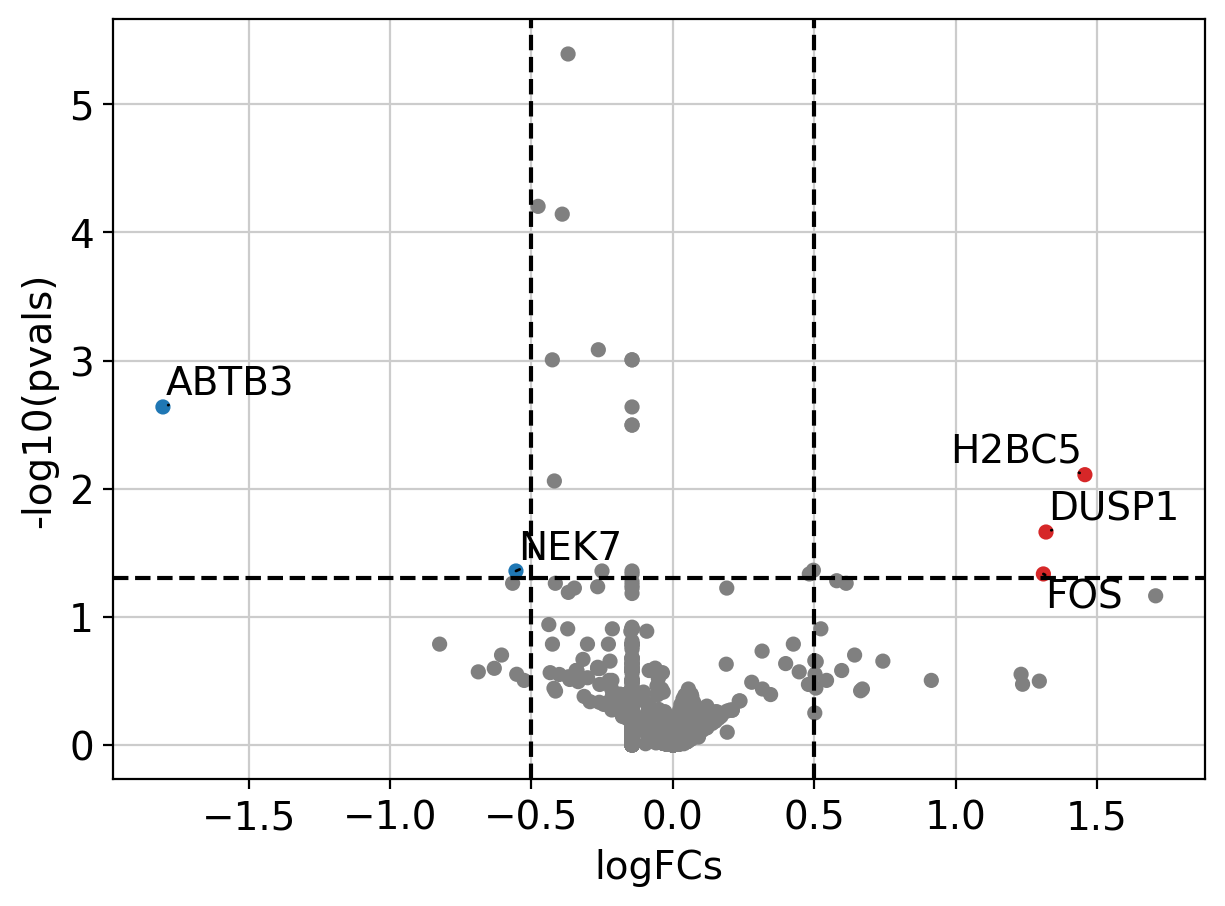

In [6]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

## Subsetting the cell type of interest  ##
cluster_idex = '10'
sp_cells = pdata[pdata.obs['leiden'] == cluster_idex].copy()

# Obtain genes that pass the thresholds
#dc.plot_filter_by_expr(sp_cells, group='label', min_count=10, min_total_count=10)
genes = dc.filter_by_expr(sp_cells, group='label', min_count=5, min_total_count=15)

# Filter by these genes
sp_cells = sp_cells[:, genes].copy()
sp_cells

## Contrast between conditions ##

# Build DESeq2 object
dds = DeseqDataSet(
    adata=sp_cells,
    design_factors=['donor','label'],
    ref_level=['label', 'CAR'],
    refit_cooks=True,
    n_cpus=8,
)

# Compute LFCs
dds.deseq2()

# Extract contrast
comparison = 'Tr2DG'
stat_res = DeseqStats(dds, contrast=["label", comparison, 'CAR'], n_cpus=8, cooks_filter= False, independent_filter=False)
stat_res.summary()

# Shrink LFCs
stat_res.lfc_shrink()

# Extract results
results_df = stat_res.results_df
results_df
results_df.to_csv(f"pdeuso_lymphoid/de_deseq2_lymphoid_{cluster_idex}_cluster_vs{comparison}.csv")

dc.plot_volcano_df(results_df, x='log2FoldChange', y='padj', top=20, save= f"pdeuso_lymphoid/de_deseq2_lymphoid_{cluster_idex}_cluster_vs{comparison}.pdf")

In [ ]:
###--- Functional enrichment of biological terms ---###

In [8]:
# Retrieve The Molecular Signatures Database (MSigDB) resource
msigdb = dc.get_resource('MSigDB')
# Extract unique categories from the 'collection' column
unique_collections = list(msigdb['collection'].cat.categories)
print(unique_collections)

['biocarta_pathways', 'cancer_gene_neighborhoods', 'cancer_modules', 'cell_type_signatures', 'chemical_and_genetic_perturbations', 'go_biological_process', 'go_cellular_component', 'go_molecular_function', 'hallmark', 'human_phenotype_ontology', 'immunesigdb', 'kegg_pathways', 'mirna_targets_legacy', 'mirna_targets_mirdb', 'oncogenic_signatures', 'pid_pathways', 'positional', 'reactome_pathways', 'tf_targets_gtrf', 'tf_targets_legacy', 'vaccine_response', 'wikipathways']


In [9]:
# List of desired categories
path_categories = ['hallmark', 'kegg_pathways', 'reactome_pathways']

# Filter msigdb DataFrame based on categories in path_categories list
msigdb_r = msigdb[msigdb['collection'].isin(path_categories)]

# Remove duplicated entries
msigdb_r = msigdb_r[~msigdb_r.duplicated(['geneset', 'genesymbol'])]

msigdb_r

,genesymbol,collection,geneset
200,MAFF,reactome_pathways,REACTOME_HEMOSTASIS
233,MAFF,hallmark,HALLMARK_IL2_STAT5_SIGNALING
250,MAFF,hallmark,HALLMARK_COAGULATION
270,MAFF,hallmark,HALLMARK_HYPOXIA
342,MAFF,reactome_pathways,REACTOME_FACTORS_INVOLVED_IN_MEGAKARYOCYTE_DEV...
...,...,...,...
3838483,KIR2DS2,reactome_pathways,REACTOME_DAP12_INTERACTIONS
3838489,KIR2DS2,reactome_pathways,REACTOME_INNATE_IMMUNE_SYSTEM
3838499,KIR2DS2,reactome_pathways,REACTOME_ADAPTIVE_IMMUNE_SYSTEM
3838530,KIR3DS1,reactome_pathways,REACTOME_DAP12_INTERACTIONS


ValueError: s must be a scalar, or float array-like with the same size as x and y

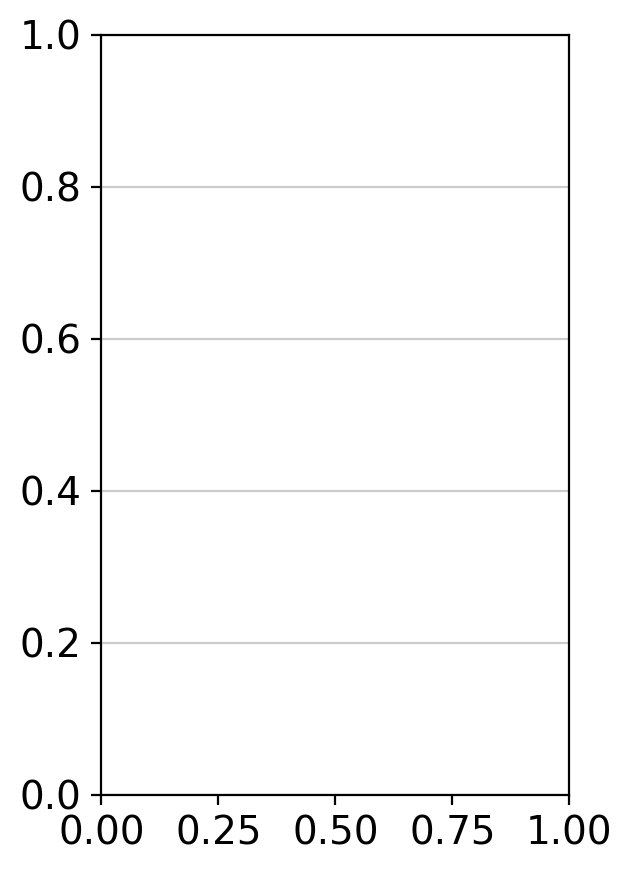

In [160]:
#import data 
cluster_idex = '14'
comparison = 'Tr2DG'

file_path = f"pdeuso_lymphoid/de_deseq2_lymphoid_{cluster_idex}_cluster_vs{comparison}.csv"
results_df = pd.read_csv(file_path, index_col=0)


# Infer enrichment with ora using significant degs
top_genes_dge = results_df[(np.abs(results_df['log2FoldChange']) > 0.5) & (results_df['padj'] < 0.05)]
top_genes_down = results_df[(results_df['log2FoldChange'] < -0.5) & (results_df['padj'] < 0.05)]
top_genes_up = results_df[(results_df['log2FoldChange'] > 0.5) & (results_df['padj'] < 0.05)]

# Run ora top_genes_up 
enr_pvals_up = dc.get_ora_df(
    df=top_genes_up,
    net=msigdb_r,
    source='geneset',
    target='genesymbol',
)
enr_pvals_up.sort_values('FDR p-value', ascending=True).head(15)
enr_pvals_up.to_csv(f"pdeuso_lymphoid/up_Enrich_lymp_{cluster_idex}_cluster_vs{comparison}.csv")


# Sorting and assigning new column for upregulated genes
enr_pvals_up_fdr = enr_pvals_up[enr_pvals_up['FDR p-value'] < 0.1].copy()
enr_pvals_up_fdr["-log10(FDR)"] = -np.log10(enr_pvals_up_fdr["FDR p-value"])
enr_pvals_up_fdr["log10(score)"] = np.log10(enr_pvals_up_fdr["Combined score"])

# Plot
upplot = dc.plot_dotplot(
        enr_pvals_up_fdr.sort_values('Combined score', ascending=False).head(10),  
        x='-log10(FDR)',
        y='Term',
        s='log10(score)',
        c='-log10(FDR)',
        scale=1,    
        cmap='copper',
        title=f"up_Enrich_lymp_{cluster_idex}_cluster_vs{comparison}",
        save=f"pdeuso_lymphoid/up_Enrich_lymp_{cluster_idex}_cluster_vs{comparison}.pdf"
    )


# Run ora top_genes_down
enr_pvals_down = dc.get_ora_df(
    df=top_genes_down,
    net=msigdb_r,
    source='geneset',
    target='genesymbol',
)
enr_pvals_down.to_csv(f"pdeuso_lymphoid/down_Enrich_lymp_{cluster_idex}_cluster_vs{comparison}.csv")
enr_pvals_down.sort_values('FDR p-value', ascending=True).head(15)

# Sorting and assigning new column for downregulated genes
enr_pvals_down_fdr = enr_pvals_down[enr_pvals_down['FDR p-value'] < 0.1].copy()
enr_pvals_down_fdr["-log10(FDR)"] = -np.log10(enr_pvals_down_fdr["FDR p-value"])
enr_pvals_down_fdr["log10(score)"] = np.log10(enr_pvals_down_fdr["Combined score"])

# Plot
downplot = dc.plot_dotplot(
        enr_pvals_down_fdr.sort_values('Combined score', ascending=False).head(10),  
        x='-log10(FDR)',
        y='Term',
        s='log10(score)',
        c='-log10(FDR)',
        scale=1,
        cmap='copper',
        title=f"down_Enrich_lymp_{cluster_idex}_cluster_vs{comparison}",
        save=f"pdeuso_lymphoid/down_Enrich_lymp_{cluster_idex}_cluster_vs{comparison}.pdf"
    )